In [ ]:
#Задание 1
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv('/content/stoimost_zhilya.csv')
pd.options.display.max_colwidth = None
df.head(6)

,id,Количество.комнат,Студия,Общая.площадь,Этаж,Этажей.в.доме,Парковка,Без.ремонта,Дизайнерский,Евроремонт,Косметический,Балкон,Лоджия,Совмещенный.санузел,Раздельный.санузел,Лифт,Грузовой.лифт,Мусоропровод,Год.постройки,Аварийный,Железобетонные.перекрытия,Смешанные.перекрытия,Деревянные.перекрытия,Иные.перекрытия,Панельные.стены,Блочные.стены,Деревянные.стены,Кирпичные.стены,Монолитные.стены,Смешанные.стены,Школа.1000,ВУЗ.1000,ТЦ.1000,Стоматология.1000,Почта.1000,Поликлиника.1000,Парк.1000,Остановка.1000,Одежда..1000,Супер3кет.1000,Кинотеатр.1000,Кафе.1000,АЗС.1000,Детский.сад.1000,Бар.1000,Банк.1000,Аптека.1000,Цена
0,896,2,0,46.0,3,5,0,0,0,0,1,1,0,1,0,0,0,0,1963,0,1,0,0,0,1,0,0,0,0,0,8,5,2,7,3,1,1,11,2,3,0,7,3,13,2,7,18,2350000.0
1,399,2,0,44.6,5,5,0,0,0,0,1,1,0,1,0,0,0,0,1969,0,1,0,0,0,1,0,0,0,0,0,3,1,1,5,2,2,1,8,3,5,0,7,3,11,1,4,11,1799000.0
2,1515,2,0,53.0,1,9,0,1,0,0,0,0,0,0,0,1,0,1,1977,0,1,0,0,0,1,0,0,0,0,0,6,1,5,8,4,6,1,13,4,11,0,5,3,17,3,7,15,2800000.0
3,1216,2,0,64.0,4,5,0,0,0,1,0,1,0,1,0,0,0,0,1966,0,1,0,0,0,0,0,0,1,0,0,5,25,8,15,3,7,1,16,31,5,1,55,2,10,28,32,17,3970000.0
4,677,1,0,33.3,1,10,0,0,1,0,0,0,0,1,0,0,2,1,2006,0,1,0,0,0,0,0,0,0,1,0,1,0,0,2,1,1,0,2,1,3,0,2,3,9,0,3,6,1880000.0
5,1210,2,0,46.0,3,4,0,0,0,0,1,1,0,1,0,0,0,0,1960,0,1,0,0,0,0,0,0,1,0,0,7,4,3,16,2,3,3,18,38,6,2,15,0,27,9,11,25,2400000.0


In [ ]:
#Задание 2
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 808 entries, 0 to 807
Data columns (total 48 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         808 non-null    int64  
 1   Количество.комнат          808 non-null    int64  
 2   Студия                     808 non-null    int64  
 3   Общая.площадь              808 non-null    float64
 4   Этаж                       808 non-null    int64  
 5   Этажей.в.доме              808 non-null    int64  
 6   Парковка                   808 non-null    int64  
 7   Без.ремонта                808 non-null    int64  
 8   Дизайнерский               808 non-null    int64  
 9   Евроремонт                 808 non-null    int64  
 10  Косметический              808 non-null    int64  
 11  Балкон                     808 non-null    int64  
 12  Лоджия                     808 non-null    int64  
 13  Совмещенный.санузел        808 non-null    int64  

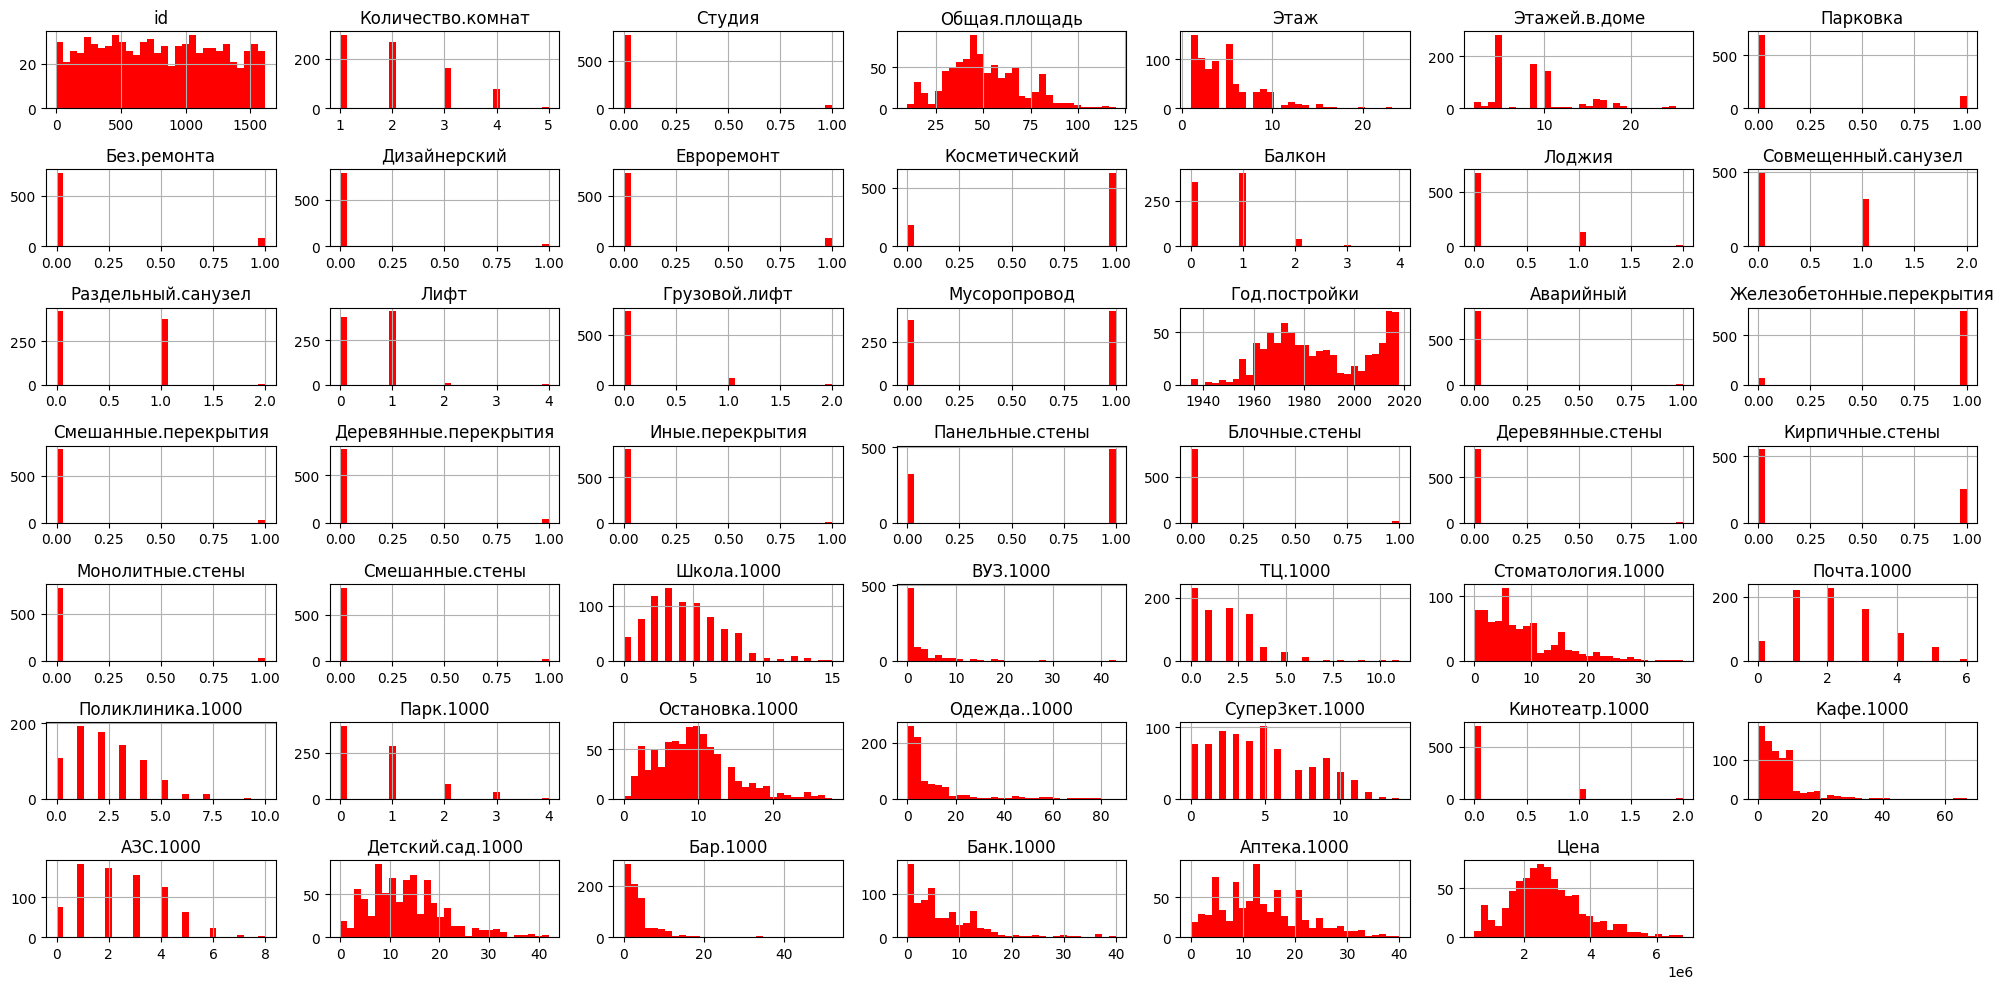

In [ ]:
df.hist(figsize=(20, 10), bins=30, color = 'red')
plt.tight_layout()
plt.show()

С точки зрения обработчика данных:

Датасет содержит 808 строк, 48 колонн. Типы данных - числовые float64(2), int64(46). Использует 303.1 KB памяти.
Сделать: стандартизацию данных, отбор признаков (проведение анализа важности признаков для определения, какие из них наиболее значимы для последующих моделей), очистку данных (проверка на наличие дубликатов, пропусков или аномалий в данных).

С точки зрения аналитика данных:

Датасет представляет список квартир, их характеристики и цену. Сделать:
1. анализ факторов, влияющих на цену жилья: площадь, этаж, балкон, ремонт, наличие инфраструктуры;
2. деление жилья на категории
3. выявление трендов и временной анализ

In [ ]:
#Задание 3
df.describe(include='all')

,id,Количество.комнат,Студия,Общая.площадь,Этаж,Этажей.в.доме,Парковка,Без.ремонта,Дизайнерский,Евроремонт,Косметический,Балкон,Лоджия,Совмещенный.санузел,Раздельный.санузел,Лифт,Грузовой.лифт,Мусоропровод,Год.постройки,Аварийный,Железобетонные.перекрытия,Смешанные.перекрытия,Деревянные.перекрытия,Иные.перекрытия,Панельные.стены,Блочные.стены,Деревянные.стены,Кирпичные.стены,Монолитные.стены,Смешанные.стены,Школа.1000,ВУЗ.1000,ТЦ.1000,Стоматология.1000,Почта.1000,Поликлиника.1000,Парк.1000,Остановка.1000,Одежда..1000,Супер3кет.1000,Кинотеатр.1000,Кафе.1000,АЗС.1000,Детский.сад.1000,Бар.1000,Банк.1000,Аптека.1000,Цена
count,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.00000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,8.080000e+02
mean,794.887376,2.039604,0.040842,50.781176,4.894802,8.935644,0.142327,0.101485,0.024752,0.101485,0.772277,0.632426,0.181931,0.394802,0.480198,0.553218,0.101485,0.530941,1986.219059,0.003713,0.919554,0.030941,0.045792,0.003713,0.602723,0.017327,0.002475,0.316832,0.040842,0.019802,4.154703,2.94802,1.777228,8.298267,2.175743,2.293317,0.728960,9.275990,10.372525,4.674505,0.143564,7.788366,2.501238,13.263614,4.149752,6.754950,13.470297,2.699083e+06
std,461.218298,0.996109,0.198046,19.827507,3.760826,4.754526,0.349601,0.302157,0.155466,0.302157,0.419622,0.635417,0.410905,0.491638,0.512161,0.565106,0.333355,0.499351,20.256724,0.060858,0.272150,0.173264,0.209163,0.060858,0.489637,0.130567,0.049721,0.465529,0.198046,0.139406,2.630406,5.78399,1.718008,6.719658,1.329787,1.697540,0.887503,5.179008,15.397133,3.255991,0.378064,8.983450,1.636025,7.557860,5.955523,6.873569,8.068579,1.096460e+06
min,1.000000,1.000000,0.000000,10.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1935.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.990000e+05
25%,406.500000,1.000000,0.000000,37.650000,2.000000,5.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1970.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.00000,0.000000,3.000000,1.000000,1.000000,0.000000,6.000000,2.000000,2.000000,0.000000,3.000000,1.000000,8.000000,1.000000,2.000000,7.000000,1.950000e+06
50%,774.500000,2.000000,0.000000,48.000000,4.000000,9.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1983.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.00000,2.000000,7.000000,2.000000,2.000000,1.000000,9.000000,4.000000,4.000000,0.000000,6.000000,2.000000,13.000000,3.000000,5.000000,12.000000,2.550000e+06
75%,1181.500000,3.000000,0.000000,63.075000,6.000000,10.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,2007.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,3.00000,3.000000,11.000000,3.000000,3.000000,1.000000,12.000000,12.000000,7.000000,0.000000,9.000000,4.000000,18.000000,5.000000,10.000000,19.000000,3.310000e+06
max,1615.000000,5.000000,1.000000,120.000000,24.000000,26.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,2.000000,2.000000,2.000000,4.000000,2.00

Для бизнеса: средняя цена квартиры — около 2,7 млн руб, при средней площади 51 кв.м. и 2 комнатах. Большинство объектов имеют базовые удобства (балкон — 77%, лифт — 48%), однако 14% без ремонта, а дизайнерский ремонт встречается редко (2%), что влияет на спрос. Квартиры в районах с развитой инфраструктурой потенциально стоят дороже, что важно учитывать при ценообразовании и выборе объектов для инвестиций.

Для обработчика данных:
Данные включают числовые и бинарные признаки, некоторые из них имеют большой разброс и выбросы, что требует нормализации. Бинарные признаки удобны, но могут потребовать объединения редких категорий.

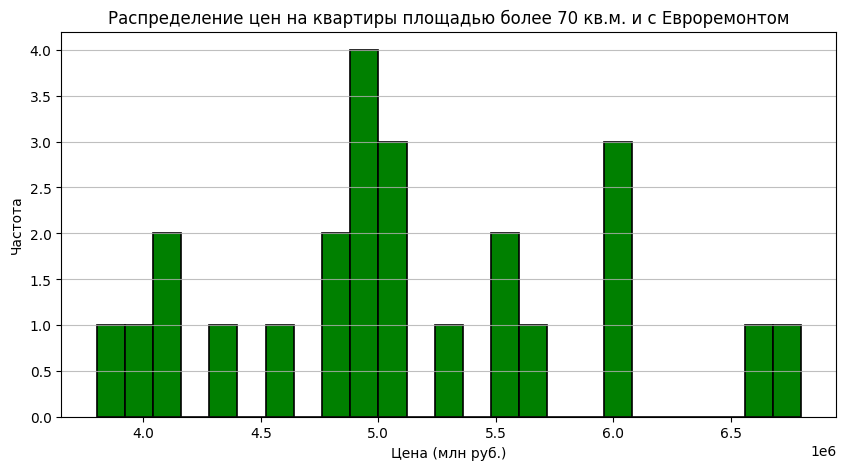

In [ ]:
#Задание 4. Вариант 1
s = df[(df['Общая.площадь'] > 70) & (df['Евроремонт'] == 1)]
plt.figure(figsize=(10, 5))
plt.hist(s['Цена'], bins=25, color='green', edgecolor='black', linewidth=1.2)
plt.title('Распределение цен на квартиры площадью более 70 кв.м. и с Евроремонтом')
plt.xlabel('Цена (млн руб.)')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.8)
plt.show()

Большая часть квартир находится в диапазоне от 4.5 млн до 5.5 млн, можно сказать о среднем значении стоимости квартиры с площадью более 70 кв.м. и евроремонтом.

In [ ]:
#Задание 5. Вариант 1
filtered_df = df[df['Количество.комнат'] == 5]
sorted_df = filtered_df.sort_values(by='Цена', ascending=False)
columns_to_show = ['id', 'Количество.комнат', 'Студия', 'Общая.площадь', 'Этаж', 'Этажей.в.доме','Парковка', 'Евроремонт', 'Косметический', 'Балкон', 'Лоджия','Лифт', 'Грузовой.лифт', 'Год.постройки','Железобетонные.перекрытия', 'Кирпичные.стены', 'Монолитные.стены','Школа.1000', 'ТЦ.1000', 'Парк.1000', 'Супер3кет.1000', 'Остановка.1000', 'Поликлиника.1000','Цена']
result_table = sorted_df[columns_to_show]
result_table

,id,Количество.комнат,Студия,Общая.площадь,Этаж,Этажей.в.доме,Парковка,Евроремонт,Косметический,Балкон,Лоджия,Лифт,Грузовой.лифт,Год.постройки,Железобетонные.перекрытия,Кирпичные.стены,Монолитные.стены,Школа.1000,ТЦ.1000,Парк.1000,Супер3кет.1000,Остановка.1000,Поликлиника.1000,Цена
42,402,5,0,116.0,5,10,1,1,0,2,0,1,0,1996,1,0,0,8,2,3,12,27,4,6800000.0
80,579,5,0,120.0,8,9,0,1,0,2,1,1,0,1999,1,0,0,2,0,0,5,9,4,5500000.0
691,1,5,0,95.2,1,10,1,0,1,0,0,1,0,1991,1,0,0,3,3,1,10,12,4,5000000.0


Под заданные параметры подходят только 3 квартиры. Ключевыми характеристиками, повлиявшими на стоимость, являются наличие парковки, этаж, инфраструктура.

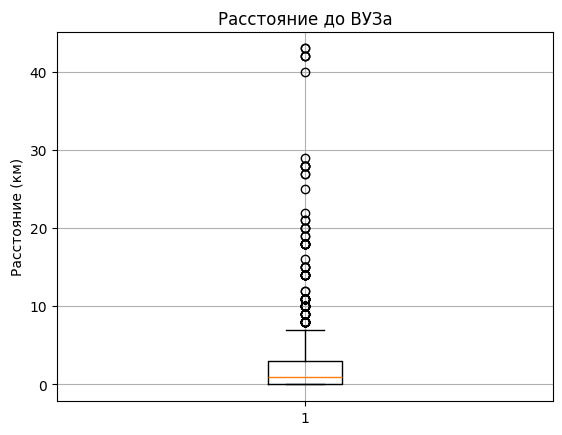

In [ ]:
#Задание 6
plt.boxplot(df['ВУЗ.1000'])
plt.title('Расстояние до ВУЗа')
plt.ylabel('Расстояние (км)')
plt.grid()
plt.show()

Предполагала, что будет иметь выбросы расстояние до ВУЗА из-за значений в 40 км, резко отходящих от основной массы. Как видно графику, данная характеристика действительно имеет выбросы.

Задание 7.
Вопросы для бизнеса:
1. Как влияет ремонт на цену квартиры?
2. Как наличие инфраструктуры в близкой доступности (школы, супермаркеты, парки, тц, стоматологии и т.д.) оказывает влияние на цену квартиры?
3. Какие характеристики больше влияют на цену квартиры?


В целом данный датасет отвечает на вопросы о влиянии характеристик жилья на его стоимость.